In [7]:
import pandas as pd
from sklearn import linear_model
import numpy as np
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

plt.rcParams.update({'figure.figsize': (12.0, 8.0)})
plt.rcParams.update({'font.size': 14})

In [8]:
X = pd.read_csv("../data/X_train.csv").drop(['id'], axis=1)
y = pd.read_csv("../data/y_train.csv").drop(['id'], axis=1)

# impute data with median value 
X = X.fillna(X.median())
X = X.drop(X.loc[:, X.var()<0.0001].columns, axis=1) # only use columns with variance
X_norm =(X-X.mean())/X.std() # normalise the data

# test train split
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2, random_state=42)

In [9]:
# Feature selection with Lasso
n = 20
lasso_result = pd.DataFrame(columns=['alpha', 'R^2', '#coef'], index=range(n))
i = 0
for a in np.linspace(0,1.5,n):
    lasso = linear_model.Lasso(alpha=a)
    lasso.fit(X_train, y_train)
    
    lasso_result.loc[i, 'alpha'] = a
    lasso_result.loc[i, 'R^2'] = lasso.score(X_test, y_test)
    lasso_result.loc[i, '#coef'] = sum(abs(lasso.coef_) > 0.01)

    i+=1




C:\Users\juliu\AppData\Local\Temp/ipykernel_10296/1818698166.py:7: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  lasso.fit(X_train, y_train)
C:\Users\juliu\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:647: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\juliu\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:647: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.791e+03, tolerance: 9.180e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
C:\Us

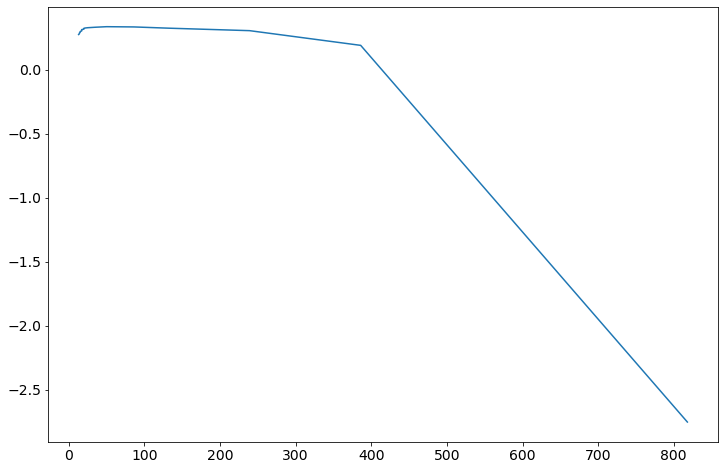

In [10]:
import matplotlib.pyplot as plt
plt.plot(lasso_result['#coef'], lasso_result['R^2'])

In [11]:
lasso_result

,alpha,R^2,#coef
0,0.0,-2.752503,818
1,0.078947,0.188822,386
2,0.157895,0.303659,239
3,0.236842,0.322774,133
4,0.315789,0.332717,86
5,0.394737,0.334623,50
6,0.473684,0.330313,35
7,0.552632,0.326592,25
8,0.631579,0.32463,22
9,0.710526,0.321998,20


In [12]:
lasso = linear_model.Lasso(alpha=0.5)
lasso.fit(X_train, y_train)
pd.DataFrame({'variable' : X.columns[abs(lasso.coef_) > 0.01], 'coef' : lasso.coef_[abs(lasso.coef_) > 0.01]}).sort_values(by='coef', ascending=False)

,variable,coef
31,x785,1.451748
1,x85,0.997589
10,x302,0.787899
12,x315,0.488188
11,x309,0.463256
30,x779,0.360995
7,x187,0.320743
8,x214,0.250698
14,x356,0.208841
25,x687,0.130881


# Feature Importance RF

In [13]:
# Let's load the packages
import numpy as np
import pandas as pd
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import shap
from matplotlib import pyplot as plt

# Random forest feature importance
rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train.values.ravel())

KeyboardInterrupt: 

Text(0.5, 0, 'Random Forest Feature Importance')

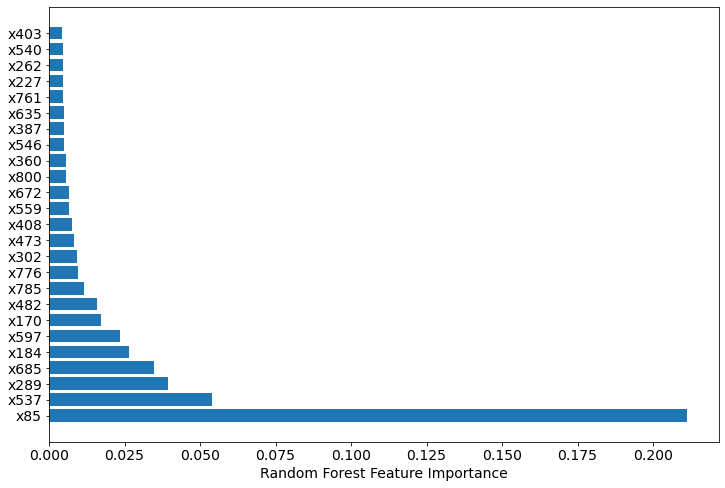

In [ ]:
top = 25
sorted_idx = rf.feature_importances_.argsort()[::-1][:top]
plt.barh(X.columns[sorted_idx], rf.feature_importances_[sorted_idx])
plt.xlabel("Random Forest Feature Importance")

In [ ]:
# other form of feature importance
perm_importance = permutation_importance(rf, X_test, y_test)

Text(0.5, 0, 'Permutation Importance')

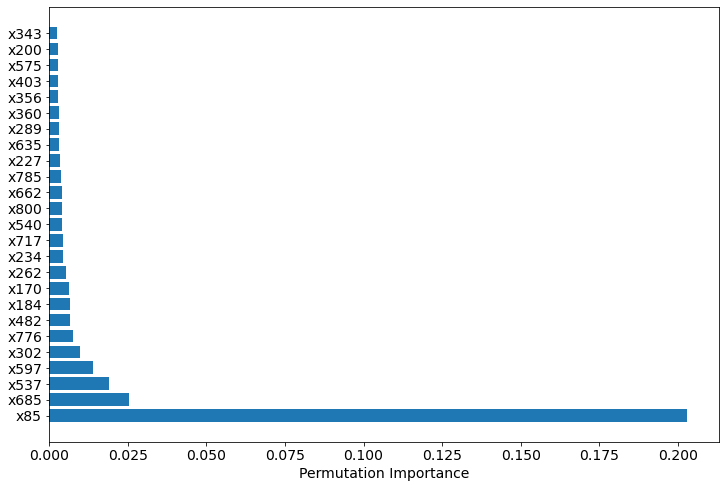

In [ ]:
sorted_idx = perm_importance.importances_mean.argsort()[::-1][:top]
plt.barh(X.columns[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance")

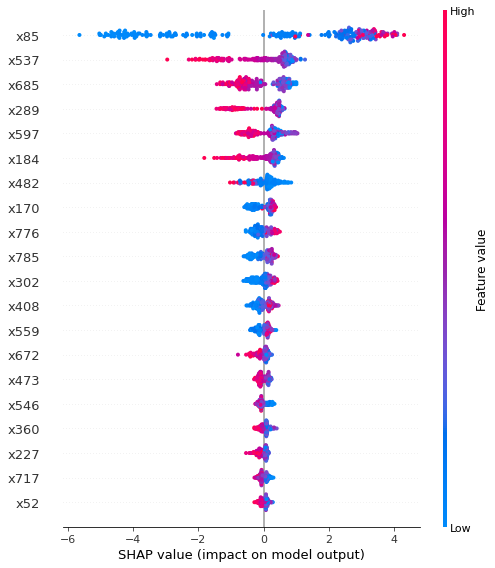

In [ ]:
# third method of feature importance
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test) # , plot_type="bar"

# Figure out which interactions are good

In [ ]:
# cant run on all columns since it would take 5 days, hence use the top 137 lasso variables
# this just creates a df that we want to engineer on
lasso = linear_model.Lasso(alpha=0.237)
lasso.fit(X_train, y_train)
selected_features = pd.DataFrame({'variable' : X.columns[abs(lasso.coef_) > 0.001], 'coef' : lasso.coef_[abs(lasso.coef_) > 0.001]}).sort_values(by='coef', ascending=False)
df = X_norm[selected_features['variable'].values]
# df.columns = df.columns.str[1:]

In [ ]:
from math import comb
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

# create an automatic feature interaction engineering that finds the best interactions in a given dataset
# given by user
folds = 3
model = LinearRegression(normalize=True)
X = df # .iloc[:, 0:10] # interacts on all those columns so pre-select if too many
y = y
deg_poly = 4 # defines the degree of the polynomials
score = 'r2'
n_jobs = 4 # now parallel
top = 50
path = '../out/X_engineered.csv'


def sort_feature_names(s, orig_features):
    # sorts s based on the order in orig_features which makes sure that features that combine the same columns have the same name and can be dropped base on the name
    index = [(lambda x: orig_features.index(x))(x) for x in s.split(':')]
    zipped_lists = zip(index, s.split(':'))
    sorted_zipped_lists = sorted(zipped_lists)
    
    return ":".join([element for _, element in sorted_zipped_lists])

def feature_engineering(X, y, model, folds, deg_poly, score, n_jobs, top, path):

    crossvalidation = KFold(n_splits=folds, shuffle=True, random_state=42)
    orig_features = list(X.columns.drop('interaction', errors='ignore'))
    tested_interactions = []

    for d in range(deg_poly): # loop over the degree of polynomials
        features = list(X.columns.drop('interaction', errors='ignore'))

        # only interact the current features with the new features to avoid working twice
        if 'new_features' in locals(): 
            features_interact = new_features 
            num_poly = comb(len(features_interact),2) + len(features_interact)*len(features)
        else: 
            features_interact = orig_features
            num_poly = comb(len(features),2) + len(features)

        baseline = np.mean(cross_val_score(model, X, y, scoring=score, cv=crossvalidation, n_jobs=n_jobs))
        data_interactions = pd.DataFrame(index=range(X.shape[0]) , columns=range(num_poly)) # stores all interactions
        eval_interactions = pd.DataFrame(columns=['feature_A:feature_B', score], index=range(num_poly)) #  stores how good the interaction was

        i=0    
        for feature_A in features_interact: # features that are interacted with current features
            for feature_B in features:
                
                name_interaction = sort_feature_names(feature_A + ":" + feature_B, orig_features)
                
                if name_interaction not in tested_interactions: # features.index(feature_A) >= features.index(feature_B): # >= to create x^2 etc. (but x^3 is only created if x^2 has been chosen) # make sure this interaction has not been done
                    tested_interactions.append(name_interaction) # save that this interaction has been calculated
                    print(feature_A, feature_B)

                    X['interaction'] = X[feature_A] * X[feature_B]
                    score_eval = np.mean(cross_val_score(model, X, y, scoring=score, cv=crossvalidation, n_jobs=n_jobs))
                    
                    if score_eval > baseline: # only store new interaction if it improves on baseline
                        
                        eval_interactions.iloc[i, : ] = pd.Series({'feature_A:feature_B' : name_interaction, score : round(score_eval,4)})
                        data_interactions.iloc[:, i] = X['interaction'] # store the good interaction data
                        data_interactions.rename(columns={i : name_interaction}, inplace=True) # give column the feature name
                        i+=1
        
        # could quickly check the "pure" polynomials for each degree

        new_features = eval_interactions.sort_values(by=score, ascending=False, ignore_index=True).loc[0:top, 'feature_A:feature_B'] # new features are the top ones of the engineered ones
        X = pd.concat([X.drop('interaction', axis=1, errors='ignore'), data_interactions[new_features]], axis=1)

        X.to_csv(path, index=False)

    return X

X = feature_engineering(X, y, model, folds, deg_poly, score, n_jobs, top)

x785 x785


C:\Users\juliu\AppData\Local\Temp/ipykernel_5812/1232890674.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['interaction'] = X[feature_A] * X[feature_B]


x785 x85
x785 x302
x785 x356
x785 x187
x785 x315
x785 x476
x785 x309
x785 x344
x785 x507
x785 x779
x785 x214
x785 x262
x785 x155
x785 x687
x785 x371
x785 x500
x785 x103
x785 x110
x785 x767
x785 x459
x785 x814
x785 x683
x785 x248
x785 x329
x785 x543
x785 x664
x785 x699
x785 x768
x785 x610
x785 x316
x785 x44
x785 x689
x785 x345
x785 x23
x785 x553
x785 x620
x785 x306
x785 x471
x785 x435
x785 x402
x785 x795
x785 x272
x785 x624
x785 x429
x785 x284
x785 x456
x785 x568
x785 x199
x785 x769
x785 x531
x785 x759
x785 x676
x785 x95
x785 x310
x785 x465
x785 x24
x785 x181
x785 x268
x785 x338
x785 x319
x785 x374
x785 x675
x785 x333
x785 x594
x785 x304
x785 x29
x785 x503
x785 x829
x785 x596
x785 x468
x785 x236
x785 x605
x785 x567
x785 x226
x785 x534
x785 x827
x785 x537
x785 x390
x785 x717
x785 x116
x785 x436
x785 x612
x785 x373
x785 x812
x785 x196
x785 x253
x785 x382
x785 x260
x785 x71
x785 x58
x785 x475
x785 x583
x785 x229
x785 x420
x785 x506
x785 x627
x785 x290
x785 x802
x785 x135
x785 x25
x785 x160

In [ ]:
s = feature_B + ":" + feature_A

def sort_feature_names(s, orig_features):
    # sorts s based on the order in orig_features which makes sure that features that combine the same columns have the same name and can be dropped base on the name
    index = [(lambda x: orig_features.index(x))(x) for x in s.split(':')]
    zipped_lists = zip(index, s.split(':'))
    sorted_zipped_lists = sorted(zipped_lists)
    
    return ":".join([element for _, element in sorted_zipped_lists])


sort_feature_names(s, orig_features)

'x785:x785:x85'

In [5]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
X = pd.read_csv('../out/X_train_engineered.csv')
y = pd.read_csv('../data/y_train.csv')['y']
# model = LinearRegression(normalize=True)
from sklearn.ensemble import RandomForestRegressor
# model = RandomForestRegressor(n_estimators=100)

interactions = pd.DataFrame(columns=['feature_', 'R^2'], index=range(X.shape[1]))
crossvalidation = KFold(n_splits=5, shuffle=True, random_state=42)
# baseline = np.mean(cross_val_score(model, X_train, y_train, scoring='r2', cv=crossvalidation,
    # n_jobs=4))
X = (X-X.mean())/X.std()
for i in range(1,X.shape[1]):
    print(i)
    # score= np.mean(cross_val_score(model, X.iloc[:,0:i], y, scoring='r2', cv=crossvalidation, n_jobs=4))
    features = X.columns[0:i]
    reg = LassoCV(cv=5, random_state=0, tol=1e-1).fit(X[features], np.ravel(y))
    score = reg.score(X[features], np.ravel(y))
    interactions.iloc[i, : ] = pd.Series({'feature' : X.columns[i], 'R^2' : round(score,3)})

interactions.to_csv('../out/interactions.csv', index=False)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


In [4]:
sum(reg.coef_>0.001)

15

In [ ]:
interactions.to_csv('../out/interactions.csv')

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from math import comb
regression = LinearRegression(normalize=True)
crossvalidation = KFold(n_splits=3, shuffle=True, random_state=1)

# cant run on all columns since it would take 5 days, hence use the top 137 lasso variables
lasso = linear_model.Lasso(alpha=0.237)
lasso.fit(X_train, y_train)
selected_features = pd.DataFrame({'variable' : X.columns[abs(lasso.coef_) > 0.001], 'coef' : lasso.coef_[abs(lasso.coef_) > 0.001]}).sort_values(by='coef', ascending=False)
df = X_norm[selected_features['variable'].values]
df.columns = df.columns.str[1:]

i=0
baseline = np.mean(cross_val_score(regression, df, y, scoring='r2', cv=crossvalidation,
 n_jobs=4))
interactions = pd.DataFrame(columns=['feature_A', 'feature_B', 'R^2'], index=range(comb(df.shape[1],2)))
for feature_A in df.columns.drop('interaction', errors='ignore'):
    for feature_B in df.columns.drop('interaction', errors='ignore'):
        if feature_A > feature_B:
            df['interaction'] = df[feature_A] * df[feature_B]
            score = np.mean(cross_val_score(regression, df, y, scoring='r2', cv=crossvalidation, n_jobs=4))

            if score > baseline:
                interactions.iloc[i, : ] = pd.Series({'feature_A' : feature_A, 'feature_B' : feature_B, 'R^2' : round(score,3)})
                i+=1


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


785 302
785 356
785 187
785 315
785 476
785 309
785 344
785 507
785 779
785 214
785 262
785 155
785 687
785 371
785 500
785 103
785 110
785 767
785 459
785 683
785 248
785 329
785 543
785 664
785 699
785 768
785 610
785 316
785 44
785 689
785 345
785 23
785 553
785 620
785 306
785 471
785 435
785 402
785 272
785 624
785 429
785 284
785 456
785 568
785 199
785 769
785 531
785 759
785 676
785 310
785 465
785 24
785 181
785 268
785 338
785 319
785 374
785 675
785 333
785 594
785 304
785 29
785 503
785 596
785 468
785 236
785 605
785 567
785 226
785 534
785 537
785 390
785 717
785 116
785 436
785 612
785 373
785 196
785 253
785 382
785 260
785 71
785 58
785 475
785 583
785 229
785 420
785 506
785 627
785 290
785 135
785 25
785 160
785 714
785 364
785 153
785 444
785 451
785 673
785 120
785 593
785 745
785 351
785 269
785 287
785 131
785 394
785 579
785 715
785 657
785 409
785 105
785 106
785 293
785 482
785 668
785 588
785 174
785 35
785 227
785 129
785 485
785 540
785 546
785 184
785 761


In [ ]:
interactions.dropna(inplace=True)
print('Baseline R2: %.3f' % baseline)
print('Top 10 interactions:\n %s' % interactions.sort_values(by='R^2', ascending=False)[0:100])

Baseline R2: 0.442
Top 10 interactions:
      feature_A feature_B    R^2
4180       482       673  0.451
4179       482       451  0.451
498        687        35  0.451
330        507        95   0.45
1101       689       356   0.45
...        ...       ...    ...
1057       316        58  0.446
1056       316        71  0.446
3637         8       506  0.446
1055       316       260  0.446
4560       685       214  0.446

[100 rows x 3 columns]


# Prediction

In [131]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV

def engineered_testdata(X_test, features):
    # takes the test data and manipulates it in the same way the training data was manipulated
    n =  X_test.shape[0]
    X_test_eng = pd.DataFrame(columns=features, index=range(n))
    for feature in features:
        cols = feature.split(':')
        feat_eng = np.ones((1,n))
        for col in cols:
            feat_eng = feat_eng * np.array(X_test[col])
        X_test_eng[feature] = feat_eng.T

    return X_test_eng

# read data
X = pd.read_csv("../out/X_engineered.csv").iloc[:, 1:]
y = pd.read_csv("../data/y_train.csv").drop(['id'], axis=1)
X_test = pd.read_csv("../data/X_test.csv").drop(['id'], axis=1)

# normalise training data
X = (X-X.mean())/X.std()

# apply the same transformation that were applied to training data also to test data
X_test = X_test.fillna(X_test.median())
X_test = X_test.drop(X_test.loc[:, X_test.var()<0.0001].columns, axis=1) # only use columns with variance
X_test =(X_test-X_test.mean())/X_test.std() # normalise the data
X_test_eng = engineered_testdata(X_test, X.columns)
X_test_eng =(X_test_eng-X_test_eng.mean())/X_test_eng.std() # normalise again after feature engineering

# fit prediction model
Lasso = LassoCV(cv=10, random_state=0).fit(X, np.ravel(y))
score = Lasso.score(X, np.ravel(y))
print('The crossvalidation score is: ', score)

# predict based on engineered test data
y_test = pd.DataFrame({'id' : range(X_test.shape[0])})
y_test['y'] = Lasso.predict(X_test_eng)
y_test.to_csv('../out/y_test.csv', index=False)

Objective did not converge. You might want to increase the number of iterations. Duality gap: 11.01728232417372, tolerance: 10.635823486238534
Objective did not converge. You might want to increase the number of iterations. Duality gap: 22.565644431499095, tolerance: 10.635823486238534
Objective did not converge. You might want to increase the number of iterations. Duality gap: 19.774243812364148, tolerance: 10.635823486238534
Objective did not converge. You might want to increase the number of iterations. Duality gap: 23.535299096649396, tolerance: 10.635823486238534
Objective did not converge. You might want to increase the number of iterations. Duality gap: 11.823854228372511, tolerance: 10.635823486238534
Objective did not converge. You might want to increase the number of iterations. Duality gap: 25.025895273724018, tolerance: 10.635823486238534
Objective did not converge. You might want to increase the number of iterations. Duality gap: 26.317589424332255, tolerance: 10.635823486

The crossvalidation score is:  0.7703310196982741


In [129]:
X.describe()

,x785,x85,x302,x356,x187,x315,x476,x309,x344,x507,...,x262:x687:x664:x537:x35:x227:x227:x227:x227:x129,x507:x262:x687:x227:x227:x129,x785:x85:x315:x199:x227:x227:x227:x227,x476:x262:x687:x199:x227:x227,x309:x262:x664:x199:x35:x227:x227:x227:x227:x129,x315:x262:x687:x199:x594:x227:x227:x546,x187:x262:x687:x227:x227:x129,x785:x85:x187:x187:x315:x717:x227:x227,x315:x262:x687:x594:x537:x227:x227:x546,x785:x315:x155:x689:x579:x482:x227:x227
count,1.212000e+03,1.212000e+03,1.212000e+03,1.212000e+03,1.212000e+03,1.212000e+03,1.212000e+03,1.212000e+03,1.212000e+03,1.212000e+03,...,1.212000e+03,1.212000e+03,1.212000e+03,1.212000e+03,1.212000e+03,1.212000e+03,1.212000e+03,1.212000e+03,1.212000e+03,1.212000e+03
mean,-1.639686e-17,3.242731e-17,-3.462577e-17,8.839647e-18,2.516780e-17,-2.912961e-17,8.977051e-18,6.879352e-17,-3.847308e-18,-8.290032e-18,...,-3.726149e-17,7.683165e-18,-3.495783e-17,-4.530892e-17,-5.159800e-18,-9.721322e-18,-1.141597e-17,-6.925154e-17,-3.382138e-18,1.305279e-16
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-3.328583e+00,-2.871698e+00,-2.013219e+00,-3.534010e+00,-2.238916e+00,-3.281633e+00,-4.103240e+00,-3.040972e+00,-4.333475e+00,-3.212275e+00,...,-1.009296e+01,-1.466543e+01,-3.113664e-01,-1.648518e+01,-1.150341e+01,-2.509643e+01,-1.677057e+01,-2.469502e-01,-2.583651e+01,-3.343597e+01
25%,-6.802652e-01,-4.972083e-01,-4.874782e-01,-6.573423e-01,-6.701423e-01,-6.201641e-01,-6.256028e-01,-6.699732e-01,-4.628439e-01,-5.946523e-01,...,-5.366141e-03,1.781447e-02,-6.199900e-02,6.324800e-02,-1.296050e-02,-3.376581e-02,4.230708e-02,-6.444556e-02,4.320557e-04,4.386553e-02
50%,-1.571417e-01,-3.427087e-01,-2.770594e-01,-3.060779e-02,-2.151855e-01,-8.606517e-02,-3.882233e-02,-5.372884e-02,1.143203e-01,-6.135329e-02,...,-5.364757e-03,1.940553e-02,-6.199206e-02,6.464604e-02,-1.295847e-02,-3.336504e-02,4.474107e-02,-6.442654e-02,7.866819e-04,4.391419e-02
75%,5.099940e-01,7.714758e-02,1.770555e-01,5.699804e-01,3.685784e-01,5.627028e-01,5.853268e-01,5.700436e-01,6.089763e-01,5.594583e-01,...,-5.362647e-03,2.078551e-02,-6.196970e-02,6.497827e-02,-1.295682e-02,-3.314496e-02,4.588561e-02,-6.440495e-02,1.060005e-03,4.398660e-02
max,5.212392e+00,7.174450e+00,1.347718e+01,4.701503e+00,8.537362e+00,4.259272e+00,4.208302e+00,4.052111e+00,3.397892e+00,3.962368e+00,...,3.260586e+01,1.953186e+01,3.236519e+01,1.910875e+01,3.223892e+01,1.332878e+01,2.143684e+01,3.169896e+01,8.250621e+00,3.853725e+00


In [130]:
X_test_eng.describe()

,x785,x85,x302,x356,x187,x315,x476,x309,x344,x507,...,x262:x687:x664:x537:x35:x227:x227:x227:x227:x129,x507:x262:x687:x227:x227:x129,x785:x85:x315:x199:x227:x227:x227:x227,x476:x262:x687:x199:x227:x227,x309:x262:x664:x199:x35:x227:x227:x227:x227:x129,x315:x262:x687:x199:x594:x227:x227:x546,x187:x262:x687:x227:x227:x129,x785:x85:x187:x187:x315:x717:x227:x227,x315:x262:x687:x594:x537:x227:x227:x546,x785:x315:x155:x689:x579:x482:x227:x227
count,7.760000e+02,7.760000e+02,7.760000e+02,7.760000e+02,7.760000e+02,7.760000e+02,7.760000e+02,7.760000e+02,7.760000e+02,7.760000e+02,...,7.760000e+02,7.760000e+02,7.760000e+02,776.000000,7.760000e+02,776.000000,7.760000e+02,7.760000e+02,7.760000e+02,7.760000e+02
mean,2.267373e-15,1.261815e-15,-6.407389e-16,5.774018e-15,4.633142e-16,6.830876e-15,1.164912e-14,3.020350e-15,-1.187306e-14,6.703794e-15,...,2.804700e-01,6.650151e-02,8.837332e-02,-0.298066,6.814375e-01,0.223112,1.135342e-01,1.173563e-01,1.551309e-01,4.752900e-02
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.410287e+01,2.009972e+00,1.339112e+01,3.222869,1.544046e+01,3.043632,1.693609e+00,2.914117e+00,2.836378e+00,4.546045e+00
min,-1.742602e+00,-7.300216e-01,-8.073410e-01,-2.540451e+00,-1.469105e+00,-4.477667e+00,-3.307083e+00,-2.917347e+00,-5.324020e+00,-3.060250e+00,...,-1.521900e+02,-8.871649e+00,-9.558830e+01,-55.978760,-1.080659e+02,-4.759617,-9.083106e+00,-2.105875e+01,-8.868287e+00,-3.640538e+01
25%,-7.372164e-01,-5.007060e-01,-4.992533e-01,-6.481400e-01,-6.301268e-01,-6.158462e-01,-6.264223e-01,-6.587218e-01,-5.213570e-01,-6.327271e-01,...,-4.891853e-04,-1.339887e-02,-3.861605e-03,-0.030055,-1.253840e-03,-0.003174,-1.319747e-02,-2.607949e-03,-2.614751e-03,-2.796077e-03
50%,-1.626564e-01,-3.363731e-01,-2.791548e-01,-2.683151e-02,-2.260313e-01,-4.293495e-02,-7.479644e-02,-1.018761e-01,6.626404e-02,-5.814464e-03,...,8.599685e-11,-3.138537e-08,-4.718562e-08,-0.000060,-4.488276e-11,-0.000002,3.097689e-07,1.144172e-10,7.702173e-07,3.283940e-08
75%,5.251932e-01,3.789360e-02,1.424710e-01,5.993090e-01,3.899192e-01,5.755102e-01,5.939558e-01,6.217614e-01,6.115594e-01,5.971920e-01,...,1.192423e-03,1.413324e-02,2.528533e-03,0.004482,5.787698e-04,0.001457,1.267428e-02,1.916556e-03,2.566501e-03,2.129342e-03
max,3.712541e+00,8.267798e+00,9.230415e+00,4.382515e+00,7.321707e+00,3.523125e+00,3.183471e+00,5.074522e+00,2.702232e+00,3.931574e+00,...,2.687253e+02,3.924879e+01,2.771573e+02,41.817290,3.583859e+02,54.182982,3.406134e+01,5.817410e+01,6.021952e+01,1.117154e+02
